# Final Project
This study has been conducted as part of a final project
for the Spring 2024 semester of CIS5450: Big Data Analytics, part of University
of Pennsylvania’s Master of Computer and Information Technology program.
Contributors: Abhishek Bhor, Jimeng Jiang, Nicole Korogodsky.

Deliverable #1 is this colab notebook.
Deliverable #2 is the following Medium post: https://medium.com/@nkoro/heart-health-education-is-there-something-were-missing-ee41292c7729

# **Part I:** Import libraries and data

In [ ]:
#Imports
import json
import glob
import pandas as pd
!pip install sqlalchemy==1.4.46
!pip install pandasql
import pandasql as ps
import numpy as np
import datetime as dt
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from google.colab import drive
from sklearn.model_selection import train_test_split
from collections import Counter
import seaborn as sns
from sklearn import preprocessing
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import plotly.express as px
from mlxtend.plotting import plot_confusion_matrix
from IPython.display import display

## **1.1** Mount google drive

In [ ]:
# Mount the google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1.2** Import csv file

In [ ]:
# Import raw data for Indicators of Heart Disease, just in case the other dataset because of NANs cannot be taken up.
# Source of data = https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
df = pd.read_csv('/content/drive/MyDrive/heart_2022_with_nans.csv')

## **1.3** First look at df

In [ ]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",Age 80 or older,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 55 to 59,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,Yes,No,No,No,No,Yes,No,No,No,No,No,No,No,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",NaN,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 40 to 44,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [ ]:
df.shape

(445132, 40)

In [ ]:
df.count()

State                        445132
Sex                          445132
GeneralHealth                443934
PhysicalHealthDays           434205
MentalHealthDays             436065
LastCheckupTime              436824
PhysicalActivities           444039
SleepHours                   439679
RemovedTeeth                 433772
HadHeartAttack               442067
HadAngina                    440727
HadStroke                    443575
HadAsthma                    443359
HadSkinCancer                441989
HadCOPD                      442913
HadDepressiveDisorder        442320
HadKidneyDisease             443206
HadArthritis                 442499
HadDiabetes                  444045
DeafOrHardOfHearing          424485
BlindOrVisionDifficulty      423568
DifficultyConcentrating      420892
DifficultyWalking            421120
DifficultyDressingBathing    421217
DifficultyErrands            419476
SmokerStatus                 409670
ECigaretteUsage              409472
ChestScan                   

## **1.4** Column Definitions

**Variables:**¶

There are 40 variables(columns) in this dataset.

* State : The U.S. state where the individual resides.

* Sex : Gender of the individual (Male or Female).

* GeneralHealth : Self-reported general health status of the individual.

* PhysicalHealthDays : Number of days in the past 30 days that physical health was not good.

* MentalHealthDays : Number of days in the past 30 days that mental health was not good.

* LastCheckupTime : Time since the last routine checkup or health examination.

* PhysicalActivities : Frequency of engaging in physical activities or exercises.

* SleepHours : Average number of hours of sleep per night.

* RemovedTeeth : Number of permanent teeth removed due to dental issues.

* HadHeartAttack : Whether the individual has had a heart attack.

* HadAngina : Whether the individual has experienced angina (chest pain or discomfort).

* HadStroke : Whether the individual has had a stroke.

* HadAsthma : Whether the individual has had asthma.

* HadSkinCancer : Whether the individual has had skin cancer.

* HadCOPD : Whether the individual has had Chronic Obstructive Pulmonary Disease (COPD).

* HadDepressiveDisorder : Whether the individual has had a depressive disorder.

* HadKidneyDisease : Whether the individual has had kidney disease.

* HadArthritis : Whether the individual has had arthritis.

* HadDiabetes : Whether the individual has had diabetes.

* DeafOrHardOfHearing : Whether the individual is deaf or hard of hearing.

* BlindOrVisionDifficulty : Whether the individual has blindness or vision difficulty.

* DifficultyConcentrating : Self-reported difficulty in concentrating.

* DifficultyWalking : Self-reported difficulty in walking.

* DifficultyDressingBathing : Self-reported difficulty in dressing or bathing.

* DifficultyErrands : Self-reported difficulty in running errands.

* SmokerStatus : Current smoking status of the individual (smoker, former smoker, non-smoker).

* ECigaretteUsage : Whether the individual uses e-cigarettes.

* ChestScan : Whether the individual has had a chest scan.

* RaceEthnicityCategory : Categorized race or ethnicity of the individual.

* AgeCategory : Categorized age group of the individual.

* HeightInMeters : Height of the individual in meters.

* WeightInKilograms : Weight of the individual in kilograms.

* BMI : Body Mass Index calculated from height and weight.

* AlcoholDrinkers : Whether the individual consumes alcohol.

* HIVTesting : Whether the individual has undergone HIV testing.

* FluVaxLast12 : Whether the individual received a flu vaccine in the last 12 months.

* PneumoVaxEver : Whether the individual has ever received a pneumonia vaccine.

* TetanusLast10Tdap : Time since the last tetanus vaccination (in the last 10 years, received Tdap).

* HighRiskLastYear : Whether the individual has been considered at high risk for the past year.

* CovidPos : Whether the individual tested positive for COVID-19.

# **Part II:** Data Cleaning

## **2.1** dropna

In [ ]:
# CLEAN DATA
# drop any NAN value rows from data
df.dropna(axis = 0, inplace = True)
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  object 
 1   Sex                        246022 non-null  object 
 2   GeneralHealth              246022 non-null  object 
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  object 
 6   PhysicalActivities         246022 non-null  object 
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  object 
 9   HadHeartAttack             246022 non-null  object 
 10  HadAngina                  246022 non-null  object 
 11  HadStroke                  246022 non-null  object 
 12  HadAsthma                  246022 non-null  object 
 13  HadSkinCancer              24

## **2.2** Drop duplicated rows

In [ ]:
# check numbers of duplicated rows
df[df.duplicated()]

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
5702,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,Yes,No,No,No,Yes,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 75 to 79,1.63,56.70,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
87555,Maryland,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 65 to 69,1.65,45.36,16.64,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
88402,Maryland,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 50 to 54,1.75,65.77,21.41,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
137645,New Jersey,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,No,Yes,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 75 to 79,1.63,80.74,30.55,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
174923,Rhode Island,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 75 to 79,1.57,68.04,27.44,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
184137,South Dakota,Female,Fair,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,No,No,No,Yes,No,No,No,Yes,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 70 to 74,1.75,90.72,29.53,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
208013,Vermont,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,No,No,No,No,Yes,No,No,No,No,Yes,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 70 to 74,1.65,79.38,29.12,Yes,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
216362,Washington,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 60 to 64,1.80,77.11,23.71,Yes,Yes,Yes,No,"Yes, received Tdap",No,No
225974,Washington,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 65 to 69,1.93,104.33,28.00,Yes,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [ ]:
# drop duplicated rows
df.drop_duplicates(inplace=True)

## **2.3** Drop Columns

In [ ]:
# Drop columns
columns_to_drop = ['HeightInMeters', 'WeightInKilograms'] # these columns are considered in 'BMI' column
df = df.drop(columns=columns_to_drop)

## **2.4** Renaming State Columns


In [ ]:
# Renaming States to be abbreviated (for graph readability)

abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "American Samoa": "AS",
    "Guam": "GU",
    "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR",
    "United States Minor Outlying Islands": "UM",
    "U.S. Virgin Islands": "VI",
}

def abbreviate(state):
  if state in abbreviations.keys():
    return abbreviations[state]

df['State'] = df['State'].apply(abbreviate)

## **2.5** Insert new column 'BMI_Category'.

**BMI_Categories**

*   Underweight: BMI<18.5
*   Normal: 18.5 <= BMI < 25
*   Overweight: 25 <= BMI < 30
*   Obese: BMI >= 30





In [ ]:
# Define a function to categorize BMI values
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

# Apply the function to create the new column 'BMI_Category'
df['BMI_Category'] = df['BMI'].apply(lambda x: categorize_bmi(x))

# Get the index of the 'BMI' column
bmi_column_index = df.columns.get_loc('BMI')

# Insert the 'BMI_Category' column after the 'BMI' column
df.insert(bmi_column_index + 1, 'BMI_Category', df.pop('BMI_Category'))

# Remove previous BMI column since we have replaced it with BMI_Category
df = df.drop(['BMI'], axis = 1)

In [ ]:
pd.options.display.max_columns = None # to allow visibility of all columns when doing .head()
df.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,BMI_Category,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,AL,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 65 to 69,Overweight,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,AL,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 70 to 74,Obese,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,AL,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,No,No,No,No,No,No,No,Yes,No,No,Yes,No,Yes,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 75 to 79,Obese,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,AL,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,Yes,No,Yes,No,Yes,No,No,No,No,Yes,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,Obese,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,AL,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,Obese,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## **2.6** Change datatype
1.   Change some columns' types to 'string' datatype
2.   Change some columns' types to 'int' datatype



In [ ]:
# Change some columns to 'string' datatype.
df[['State', 'Sex', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AgeCategory', 'TetanusLast10Tdap']] = (
    df[['State', 'Sex', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AgeCategory', 'TetanusLast10Tdap']].astype('string')
)

# change 'PhysicalHealthDays', 'MentalHealthDays' to int datatype as their values are basically integers
df[['PhysicalHealthDays', 'MentalHealthDays']] = (
    df[['PhysicalHealthDays', 'MentalHealthDays']].astype(int)
)

# change columns with boolean values (Yes, No) to (1,0)
# Define the mapping dictionary
mapping = {'Yes': 1, 'No': 0}
# Use the replace() method with the mapping dictionary
df.replace(mapping, inplace=True)



In [ ]:
# checking again to see if all seemingly boolean columns have been converted to int datatypes or not?
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246013 entries, 0 to 246021
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      245270 non-null  string 
 1   Sex                        246013 non-null  string 
 2   GeneralHealth              246013 non-null  string 
 3   PhysicalHealthDays         246013 non-null  int64  
 4   MentalHealthDays           246013 non-null  int64  
 5   LastCheckupTime            246013 non-null  string 
 6   PhysicalActivities         246013 non-null  int64  
 7   SleepHours                 246013 non-null  float64
 8   RemovedTeeth               246013 non-null  string 
 9   HadHeartAttack             246013 non-null  int64  
 10  HadAngina                  246013 non-null  int64  
 11  HadStroke                  246013 non-null  int64  
 12  HadAsthma                  246013 non-null  int64  
 13  HadSkinCancer              246013 

In [ ]:
# Data exploration
# checking why 'HadDiabetes' and 'CovidPos'columns are still 'object' datatype?
unique_values_HadDiabetes = df['HadDiabetes'].unique()
unique_values_CovidPos = df['CovidPos'].unique()
print('unique_values_HadDiabetes: ', unique_values_HadDiabetes)
print('unique_values_unique_values_CovidPos: ', unique_values_CovidPos)

unique_values_HadDiabetes:  [0 1 'Yes, but only during pregnancy (female)'
 'No, pre-diabetes or borderline diabetes']
unique_values_unique_values_CovidPos:  [0 1 'Tested positive using home test without a health professional']


## **2.7 ANALYSIS** ('HadDiabetes' column)

Analysing how to deal with *HadDiabetes =
*   'Yes, but only during pregnancy (female)'
*   'No, pre-diabetes or borderline diabetes'




### **2.7.1** Number of rows different values of diabetes status.

In [ ]:
# Finding number of rows for each value count in HadDiabetes.
print ('No of rows with different values for comparison', df['HadDiabetes'].value_counts(), '\n')


No of rows with different values for comparison HadDiabetes
0                                          204827
1                                           33811
No, pre-diabetes or borderline diabetes      5392
Yes, but only during pregnancy (female)      1983
Name: count, dtype: int64 



### **2.7.2** SQL query to find %

In [ ]:
# Define the SQL query
query = """
    SELECT
        HadHeartAttack as HeartAtt,
        SUM(CASE WHEN HadDiabetes = '0' THEN 1 ELSE 0 END) AS "Diab_0",
        SUM(CASE WHEN HadDiabetes = '1' THEN 1 ELSE 0 END) AS "Diab_1",
        SUM(CASE WHEN HadDiabetes = 'Yes, but only during pregnancy (female)' THEN 1 ELSE 0 END) AS "Diab_preg",
        SUM(CASE WHEN HadDiabetes = 'No, pre-diabetes or borderline diabetes' THEN 1 ELSE 0 END) AS "Diab_pre_or_brderln"
    FROM
        df
    GROUP BY
        HadHeartAttack;
"""

# Execute the query
result_df = ps.sqldf(query, locals())
result_df.set_index('HeartAtt', inplace=True)

print(result_df.to_string(header=True, col_space=10))

# Calculate percentage columns
percentage_df = pd.DataFrame()
for col in result_df.columns:
    if col.startswith("Diab_"):
        total = result_df[col].sum()
        percentage_df[col + "%"] = round((result_df[col] / total) * 100,2)

print('\n', percentage_df.to_string(header=True, col_space=10))

               Diab_0     Diab_1  Diab_preg  Diab_pre_or_brderln
HeartAtt                                                        
0              196494      29157       1927                 5000
1                8333       4654         56                  392

               Diab_0%    Diab_1%  Diab_preg%  Diab_pre_or_brderln%
HeartAtt                                                          
0               95.93      86.24       97.18                 92.73
1                4.07      13.76        2.82                  7.27


### **2.7.3** Analysis Conclusion

In [ ]:
# Replacing rows with HadDiabetes = 'Yes, but only during pregnancy (female)' to HadHeartAttack = 1
# Replacing rows with HadDiabetes = 'No, pre-diabetes or borderline diabetes' to HadHeartAttack = 0

# Replace values in the 'CovidPos' column
df['HadDiabetes'] = df['HadDiabetes'].replace('Yes, but only during pregnancy (female)', 1)
df['HadDiabetes'] = df['HadDiabetes'].replace('No, pre-diabetes or borderline diabetes', 0)

In [ ]:
# Checking unique values again
unique_values_HadDiabetes = df['HadDiabetes'].unique()
print('unique_values_HadDiabetes: ', unique_values_HadDiabetes)

unique_values_HadDiabetes:  [0 1]


## **2.8 ANALYSIS** (Dropping rows with certain values in CovidPos column)

*  Renaming rows with *CovidPos = 'Tested positive using home test without a health professional'*

In [ ]:
# Finding number of rows for each value count in CovidPos for comparison.
print ('No of rows with CovidPos with different values', df['CovidPos'].value_counts(), '\n')

No of rows with CovidPos with different values CovidPos
0                                                                167297
1                                                                 70324
Tested positive using home test without a health professional      8392
Name: count, dtype: int64 



### **2.8.1** Analysis Conclusion

In [ ]:
# Replace values in the 'CovidPos' column
df['CovidPos'] = df['CovidPos'].replace('Tested positive using home test without a health professional', 1)


In [ ]:
# Now changing the two remaining columns to int datatypes
df[['HadDiabetes', 'CovidPos']] = (
    df[['HadDiabetes', 'CovidPos']].astype(int)
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246013 entries, 0 to 246021
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      245270 non-null  string 
 1   Sex                        246013 non-null  string 
 2   GeneralHealth              246013 non-null  string 
 3   PhysicalHealthDays         246013 non-null  int64  
 4   MentalHealthDays           246013 non-null  int64  
 5   LastCheckupTime            246013 non-null  string 
 6   PhysicalActivities         246013 non-null  int64  
 7   SleepHours                 246013 non-null  float64
 8   RemovedTeeth               246013 non-null  string 
 9   HadHeartAttack             246013 non-null  int64  
 10  HadAngina                  246013 non-null  int64  
 11  HadStroke                  246013 non-null  int64  
 12  HadAsthma                  246013 non-null  int64  
 13  HadSkinCancer              246013 

In [ ]:
df.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,BMI_Category,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,AL,Female,Very good,4,0,Within past year (anytime less than 12 months ...,1,9.0,None of them,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Former smoker,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",Age 65 to 69,Overweight,0,0,1,1,"Yes, received Tdap",0,0
1,AL,Male,Very good,0,0,Within past year (anytime less than 12 months ...,1,6.0,None of them,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,Former smoker,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",Age 70 to 74,Obese,0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
2,AL,Male,Very good,0,0,Within past year (anytime less than 12 months ...,0,8.0,"6 or more, but not all",0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,Former smoker,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",Age 75 to 79,Obese,1,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
3,AL,Female,Fair,5,0,Within past year (anytime less than 12 months ...,1,9.0,None of them,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,Never smoked,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",Age 80 or older,Obese,0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,1
4,AL,Female,Good,3,15,Within past year (anytime less than 12 months ...,1,5.0,1 to 5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Never smoked,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",Age 80 or older,Obese,0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,0


## **2.9** Cleaning up Category Columns & Values

In [ ]:
# Data exploration to see all the category column values
for col in df.describe(include = 'string').columns:
    print('Column Name: ',col)
    print(df[col].unique())
    print('--'*10)
    print('\n')

Column Name:  State
<StringArray>
['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 'ID',
 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO',
 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA',
 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY', 'GU',
 'PR', <NA>]
Length: 54, dtype: string
--------------------


Column Name:  Sex
<StringArray>
['Female', 'Male']
Length: 2, dtype: string
--------------------


Column Name:  GeneralHealth
<StringArray>
['Very good', 'Fair', 'Good', 'Excellent', 'Poor']
Length: 5, dtype: string
--------------------


Column Name:  LastCheckupTime
<StringArray>
[     'Within past year (anytime less than 12 months ago)',
                                     '5 or more years ago',
  'Within past 2 years (1 year but less than 2 years ago)',
 'Within past 5 years (2 years but less than 5 years ago)']
Length: 4, dtype: string
--------------------


Column Name:  Re

In [ ]:
# clean some of data under categorical columns to make the string shorter
df['LastCheckupTime'].replace({'Within past year (anytime less than 12 months ago)': '< 12 months',
                            '5 or more years ago': '>=5 years',
                            'Within past 2 years (1 year but less than 2 years ago)': '[1-2) years',
                            'Within past 5 years (2 years but less than 5 years ago)': '[2-5) years]'}, inplace = True)

df['ECigaretteUsage'].replace({'Not at all (right now)' : 'Not now',
                              'Never used e-cigarettes in my entire life' : 'Never',
                              'Use them every day' : 'Everyday',
                              'Use them some days' : 'Some days'}, inplace=True)


df['RaceEthnicityCategory'].replace({'White only, Non-Hispanic' : 'White',
                                      'Black only, Non-Hispanic' : 'Black',
                                      'Other race only, Non-Hispanic' : 'Other',
                                      'Multiracial, Non-Hispanic' : 'Multiracial'}, inplace=True)

df['SmokerStatus'].replace({'Former smoker': 'Not now',
                            'Never smoked': 'Never',
                            'Current smoker - now smokes every day': 'Everyday',
                            'Current smoker - now smokes some days': 'Some days'}, inplace = True)

df['TetanusLast10Tdap'].replace({'Yes, received Tdap': 'Yes received Tdap',
                            'Yes, received tetanus shot but not sure what type': 'Yes but type unknown',
                            'No, did not receive any tetanus shot in the past 10 years': 'Not in past 10 years',
                            'Yes, received tetanus shot, but not Tdap': 'Yes but not type Tdap'}, inplace = True)

for age in df['AgeCategory'].unique():
      lst = age.split(" ")
      df['AgeCategory'].replace({age : lst[1]+ "-" + lst[3]}, inplace=True)

# **Part III:**EDA

## **3.1** Distribution Of Data w.r.t States

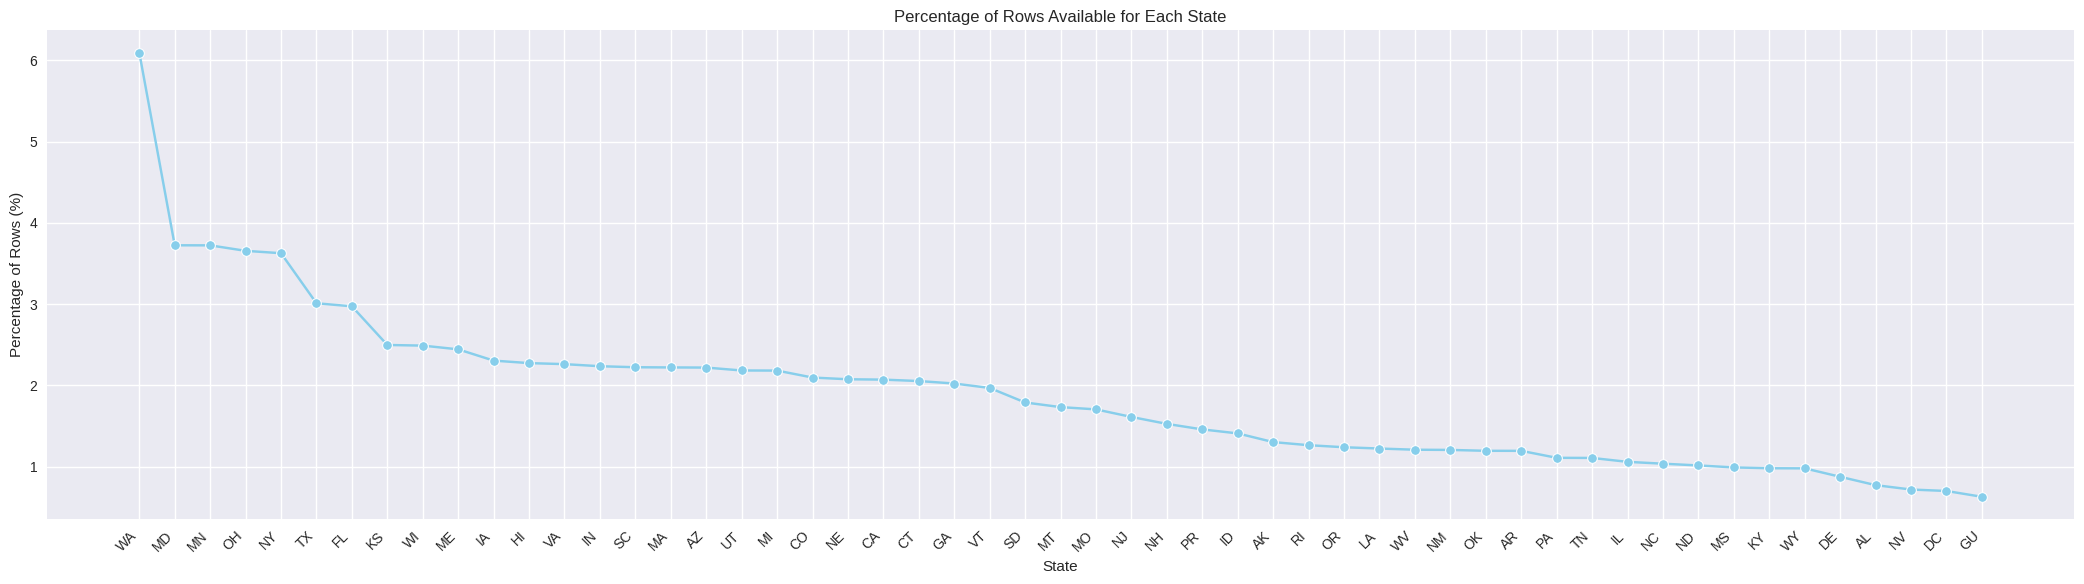

In [ ]:
# Grouping the data by 'State' and calculate the percentage of rows available for each state
state_percentage = df.groupby('State').size() / len(df) * 100

# Sorting the Series in descending order of percentages
state_percentage_sorted = state_percentage.sort_values(ascending=False)

# Plot using seaborn lineplot
plt.figure(figsize=(21, 6))
sns.lineplot(data=state_percentage_sorted, marker='o', color='skyblue')

# Set title and labels
plt.title('Percentage of Rows Available for Each State')
plt.xlabel('State')
plt.ylabel('Percentage of Rows (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Title

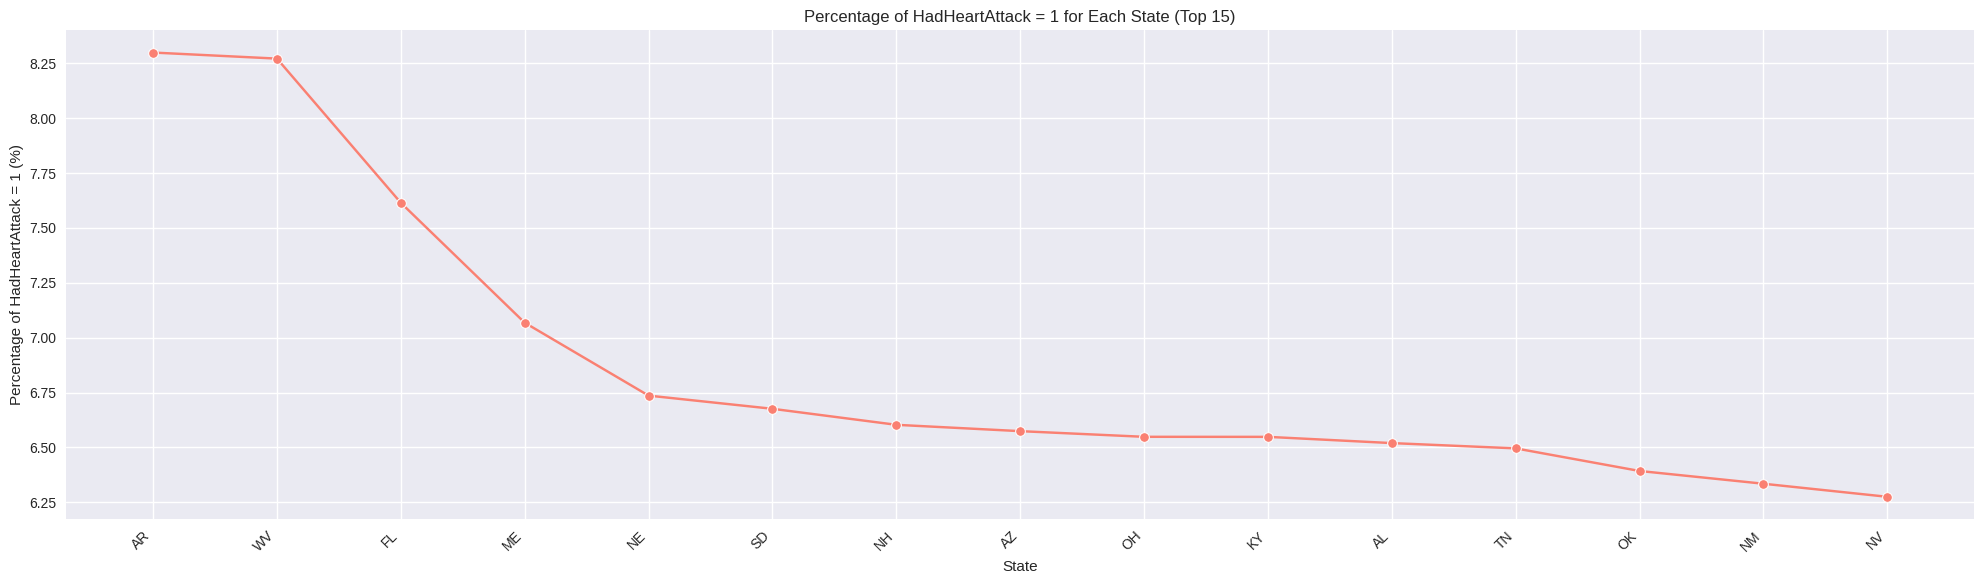

In [ ]:
df_had_heart_attack = df[df['HadHeartAttack'] == 1]
df_had_heart_attack = df[df['HadHeartAttack'] == 1]


# Group the filtered data by 'State' and calculate the percentage of rows with HadHeartAttack = 1 for each state
state_percentage_heart_attack = (df_had_heart_attack.groupby('State').size() / df.groupby('State').size()) * 100

# Reset the index to convert the series to a DataFrame
state_percentage_heart_attack = state_percentage_heart_attack.reset_index(name='Percentage')

# Sort the DataFrame by 'Percentage' in descending order
state_percentage_heart_attack_sorted = state_percentage_heart_attack.sort_values(by='Percentage', ascending=False)

# Select only the top 15 states
top_15_states = state_percentage_heart_attack_sorted.head(15)

# Plot using seaborn lineplot
plt.figure(figsize=(20, 6))
sns.lineplot(data=top_15_states, x='State', y='Percentage', marker='o', color='salmon')

# Set title and labels
plt.title('Percentage of HadHeartAttack = 1 for Each State (Top 15)')
plt.xlabel('State')
plt.ylabel('Percentage of HadHeartAttack = 1 (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


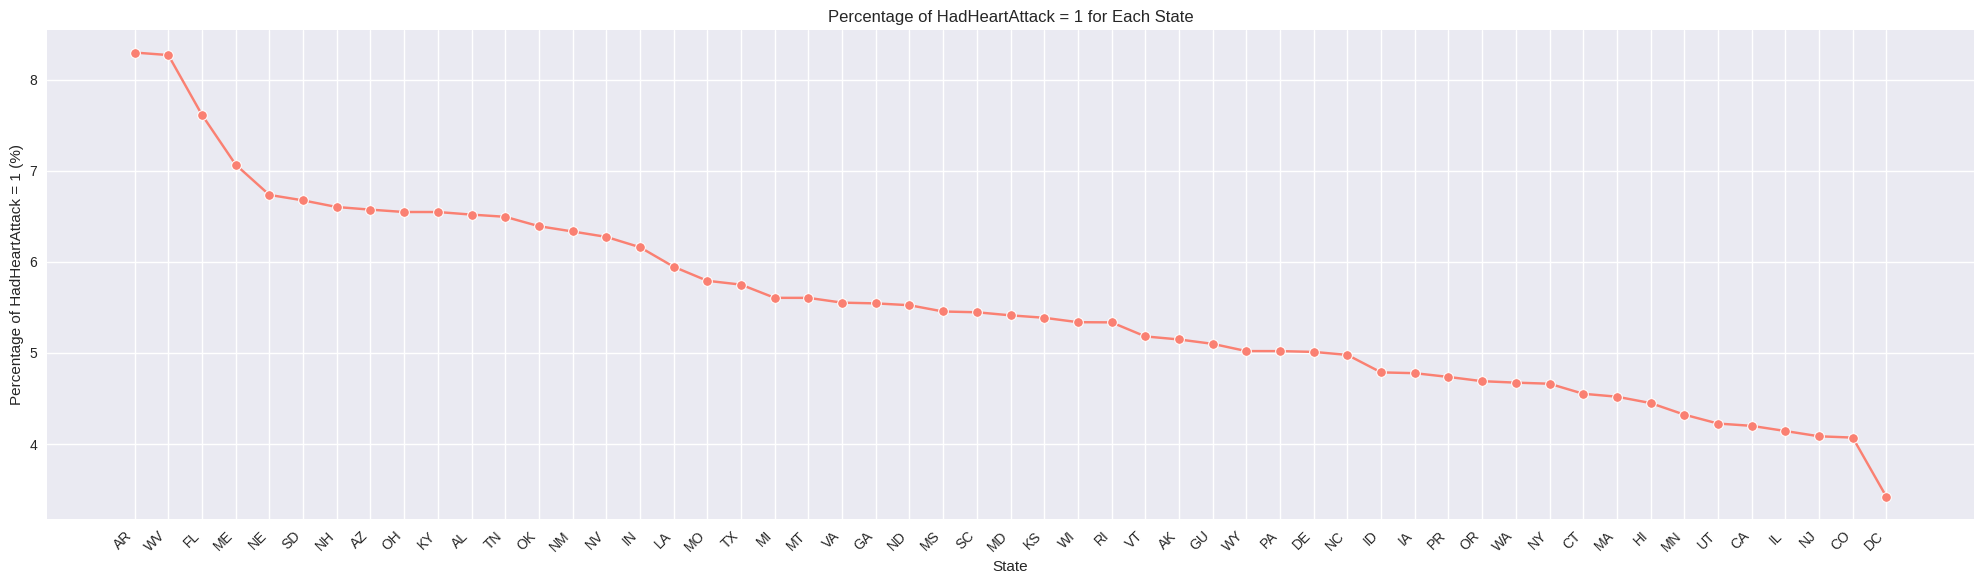

In [ ]:
# Filter the DataFrame for rows where HadHeartAttack is equal to 1
df_had_heart_attack = df[df['HadHeartAttack'] == 1]

# Group the filtered data by 'State' and calculate the percentage of rows with HadHeartAttack = 1 for each state
state_percentage_heart_attack = (df_had_heart_attack.groupby('State').size() / df.groupby('State').size()) * 100

# Reset the index to convert the series to a DataFrame
state_percentage_heart_attack = state_percentage_heart_attack.reset_index(name='Percentage')

# Sort the DataFrame by 'Percentage' in descending order
state_percentage_heart_attack_sorted = state_percentage_heart_attack.sort_values(by='Percentage', ascending=False)

# Plot using seaborn lineplot
plt.figure(figsize=(20, 6))
sns.lineplot(data=state_percentage_heart_attack_sorted, x='State', y='Percentage', marker='o', color='salmon')

# Set title and labels
plt.title('Percentage of HadHeartAttack = 1 for Each State')
plt.xlabel('State')
plt.ylabel('Percentage of HadHeartAttack = 1 (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## **3.2** Heart Attack w.r.t. BMI

In [ ]:
query = """
    SELECT
        BMI_Category,
        AVG(HadHeartAttack) * 100 AS Percentage_HadHeartAttack
    FROM (
        SELECT
            BMI_Category,
            HadHeartAttack
        FROM
            df
    )
    GROUP BY
        BMI_Category
    ORDER BY
        Percentage_HadHeartAttack DESC;
"""

# Execute the query
result_df = ps.sqldf(query, locals())

print(result_df)

  BMI_Category  Percentage_HadHeartAttack
0        Obese                   6.336150
1   Overweight                   5.653755
2  Underweight                   5.354289
3       Normal                   4.179092


## **3.3** Heart Attack by Gender

In [ ]:
# Calculate percentages
percentage_df = df.groupby(['Sex', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Reset the index to make 'Sex' and 'HadHeartAttack' columns
percentage_df = percentage_df.reset_index()

# Plot using Plotly pie chart
fig = px.pie(percentage_df, values='Percentage_Yes', names='Sex',
             title='Percentage of Heart Attacks With Respect to Gender',
             labels={'Percentage_Yes': 'Percentage of Heart Attack', 'Sex': 'Gender'},
             hole=0.3)
# Adjust plot size
fig.update_layout(width=600, height=400)

fig.show()

## **3.4** Heart Attack by Age Group

### **3.4.1** SQL query to find %

### **3.4.2** graph with %

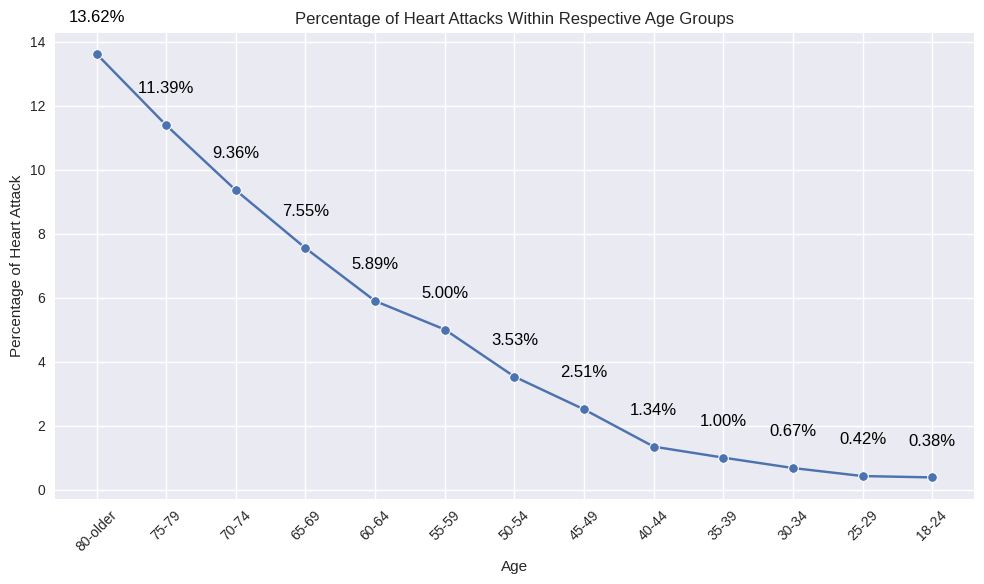

In [ ]:
# Calculate percentages
percentage_df = df.groupby(['AgeCategory', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Reset the index to make 'AgeCategory' a column
percentage_df = percentage_df.reset_index()

# Plot using seaborn lineplot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=percentage_df, x='AgeCategory', y='Percentage_Yes', marker='o')

# Set title and labels
plt.title('Percentage of Heart Attacks Within Respective Age Groups')
plt.xlabel('Age')
plt.ylabel('Percentage of Heart Attack')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Annotate each point with percentage value
for index, row in percentage_df.iterrows():
    ax.text(row.name, row['Percentage_Yes'] + 1, f"{row['Percentage_Yes']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

## **3.5** Heart Attack by Racial Groups

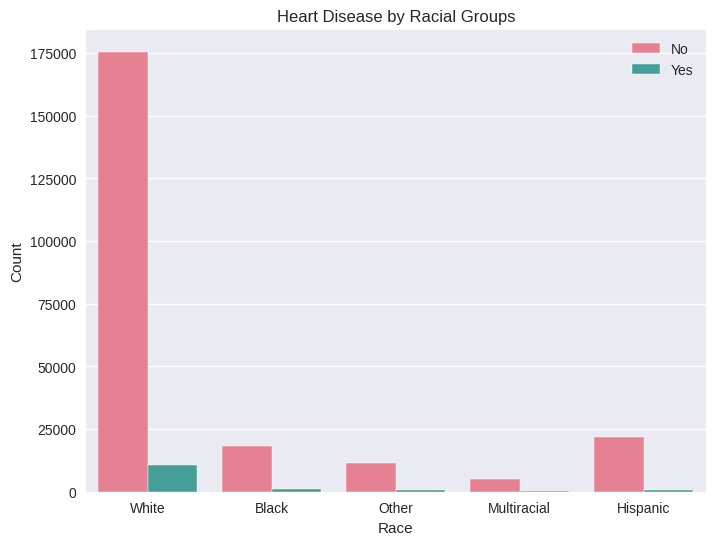

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data = df,
              x='RaceEthnicityCategory', hue='HadHeartAttack', palette='husl')
plt.title('Heart Disease by Racial Groups')
plt.xlabel('Race')
plt.legend(["No", "Yes"])
plt.ylabel('Count')
plt.show()

### **3.5.1** SQL query to find %

In [ ]:
# Define the SQL query
query = """
    SELECT
        HadHeartAttack as HeartAtt,
        SUM(CASE WHEN RaceEthnicityCategory = 'White' THEN 1 ELSE 0 END) AS "White",
        SUM(CASE WHEN RaceEthnicityCategory = 'Black' THEN 1 ELSE 0 END) AS "Black",
        SUM(CASE WHEN RaceEthnicityCategory = 'Other' THEN 1 ELSE 0 END) AS "Other",
        SUM(CASE WHEN RaceEthnicityCategory = 'Multiracial' THEN 1 ELSE 0 END) AS "Multi",
        SUM(CASE WHEN RaceEthnicityCategory = 'Hispanic' THEN 1 ELSE 0 END) AS "Hisp"
    FROM
        df
    GROUP BY
        HadHeartAttack;
"""

# Execute the query
result_df = ps.sqldf(query, locals())
result_df.set_index('HeartAtt', inplace=True)

print(result_df.to_string(header=True, col_space=10))

# Calculate percentage columns
percentage_df = pd.DataFrame()
for col in result_df.columns:
      total = result_df[col].sum()
      percentage_df[col + "%"] = round((result_df[col] / total) * 100,2)

print('\n', percentage_df.to_string(header=True, col_space=10))

                White      Black      Other      Multi       Hisp
HeartAtt                                                         
0              175571      18441      11614       5241      21711
1               10756        889        591        340        859

                White%     Black%     Other%     Multi%      Hisp%
HeartAtt                                                         
0               94.23       95.4      95.16      93.91      96.19
1                5.77        4.6       4.84       6.09       3.81


In [ ]:
# Define the SQL query
query = """
    SELECT
        HadHeartAttack as HeartAtt,
        SUM(CASE WHEN RaceEthnicityCategory = 'White' THEN 1 ELSE 0 END) AS "White",
        SUM(CASE WHEN RaceEthnicityCategory = 'Black' THEN 1 ELSE 0 END) AS "Black",
        SUM(CASE WHEN RaceEthnicityCategory = 'Other' THEN 1 ELSE 0 END) AS "Other",
        SUM(CASE WHEN RaceEthnicityCategory = 'Multiracial' THEN 1 ELSE 0 END) AS "Multi",
        SUM(CASE WHEN RaceEthnicityCategory = 'Hispanic' THEN 1 ELSE 0 END) AS "Hisp"
    FROM
        df
    GROUP BY
        HadHeartAttack;
"""

# Execute the query
result_df = ps.sqldf(query, locals())

# Set 'HeartAtt' as the index
result_df.set_index('HeartAtt', inplace=True)

# Calculate totals row
result_df.loc['Total'] = result_df.sum()

print(result_df.to_string(header=True, col_space=10))

# Calculate percentage columns off the total population
percentage_df = pd.DataFrame()
total_population = result_df.sum(axis=1)['Total']
for col in result_df.columns:
    percentage_df[col + "%"] = round((result_df[col] / total_population) * 100, 2)

print('\n', percentage_df.to_string(header=True, col_space=10))

                White      Black      Other      Multi       Hisp
HeartAtt                                                         
0              175571      18441      11614       5241      21711
1               10756        889        591        340        859
Total          186327      19330      12205       5581      22570

                White%     Black%     Other%     Multi%      Hisp%
HeartAtt                                                         
0               71.37       7.50       4.72       2.13       8.83
1                4.37       0.36       0.24       0.14       0.35
Total           75.74       7.86       4.96       2.27       9.17


### **3.5.2** graph with %

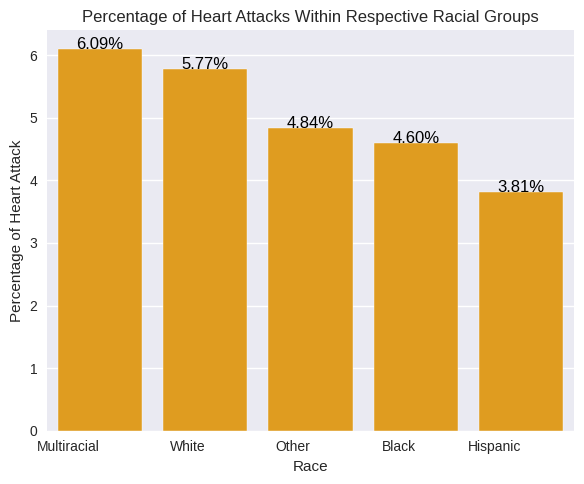

In [ ]:
# Calculate percentages
percentage_df = df.groupby(['RaceEthnicityCategory', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Plot
plt.figure(figsize=(6, 5))
ax = sns.barplot(data=percentage_df.reset_index(), x='RaceEthnicityCategory', y='Percentage_Yes', color='orange')
plt.title('Percentage of Heart Attacks Within Respective Racial Groups')
plt.xlabel('Race')
plt.ylabel('Percentage of Heart Attack')
plt.xticks(rotation=0, ha='right')

# Annotate each column with percentage value
for index, row in percentage_df.iterrows():
    ax.text(index, row['Percentage_Yes'], f"{row['Percentage_Yes']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

### **3.5.3** Racial Group & Average Age Group

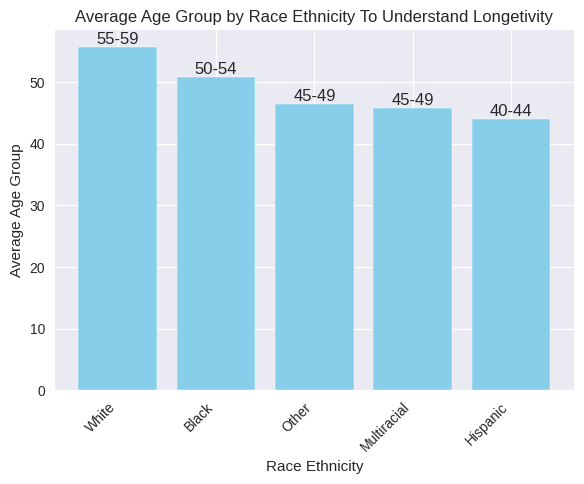

In [ ]:
# Select particular age groups
selected_age_groups = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-older']

df_filtered = df[df['AgeCategory'].isin(selected_age_groups)]

# Define the SQL query
query = """
    SELECT RaceEthnicityCategory, AgeCategory, AVG(CAST(SUBSTR(AgeCategory, 1, 2) AS INT)) AS AverageAgeGroup
    FROM df_filtered
    GROUP BY RaceEthnicityCategory
    ORDER BY AverageAgeGroup DESC;
"""

# Execute the query
result_df = ps.sqldf(query, locals())

# Calculate the closest AgeCategory value for each Race
age_categories = df_filtered['AgeCategory'].unique()
closest_age_categories = []
for idx, row in result_df.iterrows():
    average_age_group = row['AverageAgeGroup']
    closest_age_category = min(age_categories, key=lambda x: abs(int(x.split('-')[0]) + 2.5 - average_age_group))
    closest_age_categories.append(closest_age_category)

result_df['ClosestAgeCategory'] = closest_age_categories

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(result_df['RaceEthnicityCategory'], result_df['AverageAgeGroup'], color='skyblue')
plt.title('Average Age Group by Race Ethnicity To Understand Longetivity')
plt.xlabel('Race Ethnicity')
plt.ylabel('Average Age Group')
plt.xticks(rotation=45, ha='right')

# Annotate each column with the closest AgeCategory value
for i, bar in enumerate(bars):
    height = bar.get_height()
    age_category = result_df.iloc[i]['ClosestAgeCategory']
    plt.text(bar.get_x() + bar.get_width() / 2, height, age_category,
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## **3.6** Heart Attack versus RemovedTeeth

Plot using Plotly (interactive graph) for the population 45-older


In [ ]:
# Select particular age groups
selected_age_groups = ['45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-older']

df_filtered = df[df['AgeCategory'].isin(selected_age_groups)]

# Calculate percentages
percentage_df = df_filtered.groupby(['RemovedTeeth', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Reset the index to make 'RemovedTeeth' a column
percentage_df = percentage_df.reset_index()

# Plot using Plotly
fig = px.pie(percentage_df, values='Percentage_Yes', names='RemovedTeeth',
             title='Percentage of Heart Attacks Within RemovedTeeth Group in Age Group 45-Older',
             labels={'Percentage_Yes': 'Percentage of Heart Attack', 'RemovedTeeth': 'Removed Teeth'},
             hole=0.3)

# Set figure size
fig.update_layout(width=1000, height=600)

fig.show()

## **3.7** Heart Attack versus SleepHours

Percentage of Heart Attack w.r.t. Sleep Hours

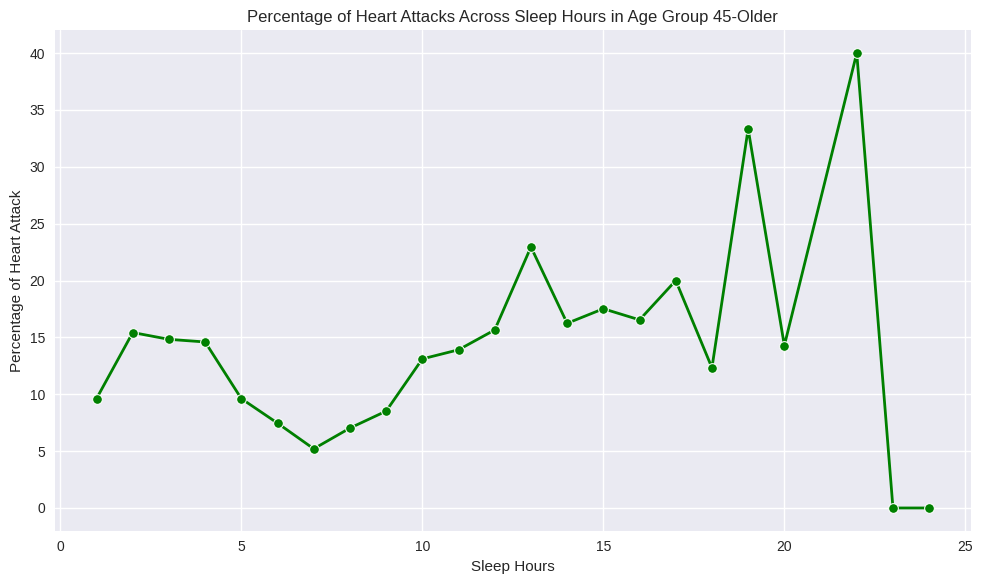

In [ ]:
# Select particular age groups
selected_age_groups = ['45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-older']

df_filtered = df[df['AgeCategory'].isin(selected_age_groups)]

# Calculate percentages
percentage_df = df_filtered.groupby(['SleepHours', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'SleepHours' to ensure the line plot is ordered
percentage_df = percentage_df.sort_index()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=percentage_df.reset_index(), x='SleepHours', y='Percentage_Yes', marker='o', color='green', linewidth=2)
plt.title('Percentage of Heart Attacks Across Sleep Hours in Age Group 45-Older')
plt.xlabel('Sleep Hours')
plt.ylabel('Percentage of Heart Attack')
plt.grid(True)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

## **3.8** Heart Attack versus LastCheckupTime

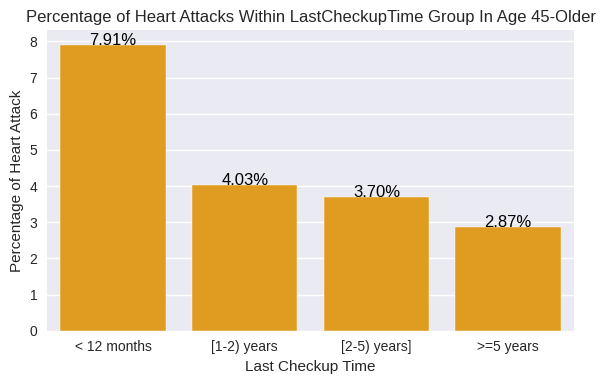

In [ ]:
# Select particular age groups
selected_age_groups = ['45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-older']

df_filtered = df[df['AgeCategory'].isin(selected_age_groups)]

# Calculate percentages
percentage_df = df_filtered.groupby(['LastCheckupTime', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=percentage_df.reset_index(), x='LastCheckupTime', y='Percentage_Yes', color='orange')
plt.title('Percentage of Heart Attacks Within LastCheckupTime Group In Age 45-Older')
plt.xlabel('Last Checkup Time')
plt.ylabel('Percentage of Heart Attack')
plt.xticks(rotation=0, ha='center')

# Annotate each column with percentage value
for index, row in percentage_df.iterrows():
    ax.text(index, row['Percentage_Yes'], f"{row['Percentage_Yes']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

## **3.9** Heart Attack w.r.t SmokerStatus

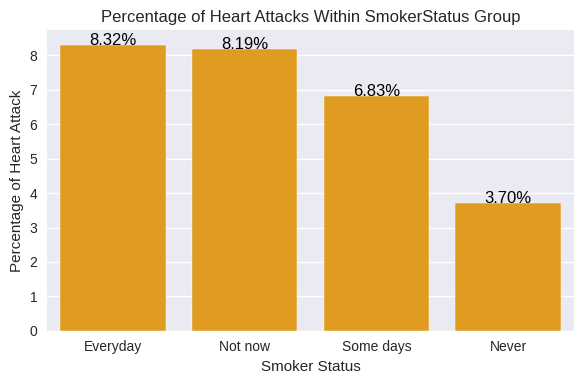

In [ ]:
# Calculate percentages
percentage_df = df.groupby(['SmokerStatus', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=percentage_df.reset_index(), x='SmokerStatus', y='Percentage_Yes', color='orange')
plt.title('Percentage of Heart Attacks Within SmokerStatus Group')
plt.xlabel('Smoker Status')
plt.ylabel('Percentage of Heart Attack')
plt.xticks(rotation=0, ha='center')

# Annotate each column with percentage value
for index, row in percentage_df.iterrows():
    ax.text(index, row['Percentage_Yes'], f"{row['Percentage_Yes']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

## **3.10** Heart Attack w.r.t. Alchohol Drinking

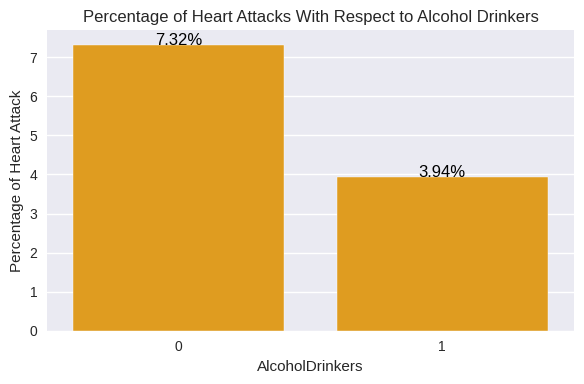

In [ ]:
# Calculate percentages
percentage_df = df.groupby(['AlcoholDrinkers', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=percentage_df.reset_index(), x='AlcoholDrinkers', y='Percentage_Yes', color='orange')
plt.title('Percentage of Heart Attacks With Respect to Alcohol Drinkers')
plt.xlabel('AlcoholDrinkers')
plt.ylabel('Percentage of Heart Attack')
plt.xticks(rotation=0, ha='center')

# Annotate each column with percentage value
for index, row in percentage_df.iterrows():
    ax.text(index, row['Percentage_Yes'], f"{row['Percentage_Yes']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

## **3.11** Heart Attack w.r.t. ChestScan

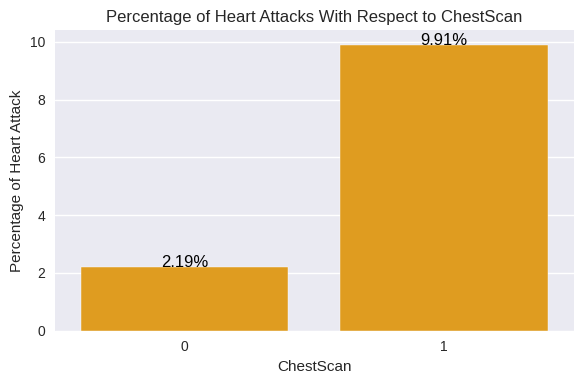

In [ ]:
# Calculate percentages
percentage_df = df.groupby(['ChestScan', 'HadHeartAttack']).size().unstack(fill_value=0)
percentage_df['Percentage_Yes'] = percentage_df[1] / (percentage_df[0] + percentage_df[1]) * 100

# Sort the DataFrame by 'Percentage_Yes' in descending order
percentage_df = percentage_df.sort_values(by='Percentage_Yes', ascending=False)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=percentage_df.reset_index(), x='ChestScan', y='Percentage_Yes', color='orange')
plt.title('Percentage of Heart Attacks With Respect to ChestScan')
plt.xlabel('ChestScan')
plt.ylabel('Percentage of Heart Attack')
plt.xticks(rotation=0, ha='center')

# Annotate each column with percentage value
for index, row in percentage_df.iterrows():
    ax.text(index, row['Percentage_Yes'], f"{row['Percentage_Yes']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

## **3.12** Heart Attack w.r.t. Health Awareness In Each State

In [ ]:
# Define the pandasql query
query = """
    SELECT
        State,
        AttacksWithNoAwareness,
        TotalAttacks,
        (AttacksWithNoAwareness * 100 / TotalAttacks) AS Percent
    FROM (
        SELECT
            State,
            SUM(CASE WHEN HadHeartAttack = 1
                     AND (PhysicalActivities = 0
                          OR SmokerStatus IN ('Not now', 'Everyday', 'Some days')
                          OR ECigaretteUsage IN ('Not now', 'Everyday', 'Some days')
                          OR BMI_Category IN ('Obese', 'Overweight')
                          OR AlcoholDrinkers = 1)
                     THEN 1 ELSE 0 END) AS AttacksWithNoAwareness,
            SUM(CASE WHEN HadHeartAttack = 1 THEN 1 ELSE 0 END) AS TotalAttacks
        FROM
            df
        GROUP BY
            State
    ) subquery
    ORDER BY
        Percent DESC;
"""

# Execute the query
result_df = ps.sqldf(query, locals())

display(result_df)


,State,AttacksWithNoAwareness,TotalAttacks,Percent
0,DE,106,108,98
1,IL,106,108,98
2,MS,131,133,98
3,PA,135,137,98
4,RI,163,166,98
5,WY,119,121,98
6,IN,330,339,97
7,LA,175,179,97
8,ME,414,425,97
9,MN,387,396,97


Text(0, 0.5, 'Percent (%)')

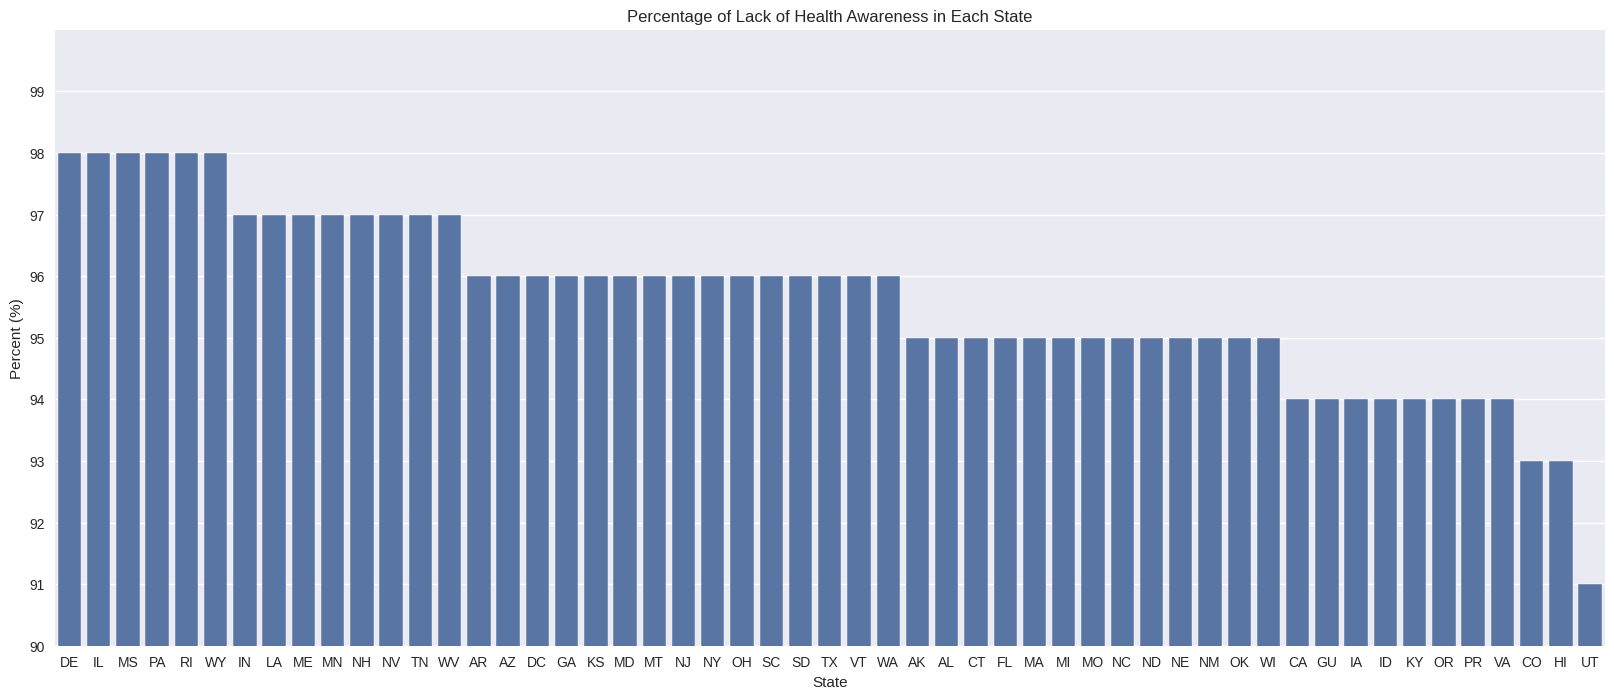

In [ ]:
# Visualizing 3.12 Table
plotting_df = result_df[['State', 'Percent']]

plt.figure(figsize=(20, 8))

ax = sns.barplot(plotting_df, x='State', y='Percent')
ax.set_yticks(range(90,100))
ax.set_ylim(90, 100)
plt.title('Percentage of Lack of Health Awareness in Each State')
plt.ylabel('Percent (%)')


## **3.13** Heart Attack w.r.t. Medical Care Access In Each State

In [ ]:
# Define the pandasql query
query = """
    SELECT
        State,
        AttacksWithNoAccess,
        TotalAttacks,
        (AttacksWithNoAccess * 100 / TotalAttacks) AS Percent
    FROM (
        SELECT
            State,
            SUM(CASE WHEN HadHeartAttack = 1
                     AND (FluVaxLast12 = 0
                          AND LastCheckupTime IN ('>=5 years', '[2-5) years')
                          AND TetanusLast10Tdap IN ('Not in past 10 years')
                          AND PneumoVaxEver = 0)
                     THEN 1 ELSE 0 END) AS AttacksWithNoAccess,
            SUM(CASE WHEN HadHeartAttack = 1 THEN 1 ELSE 0 END) AS TotalAttacks
        FROM
            df
        GROUP BY
            State
    ) subquery
    ORDER BY
        Percent DESC;
"""

# Execute the query
result_df = ps.sqldf(query, locals())

display(result_df)

,State,AttacksWithNoAccess,TotalAttacks,Percent
0,NC,3,127,2
1,UT,5,227,2
2,WY,3,121,2
3,GU,1,79,1
4,LA,2,179,1
5,MN,5,396,1
6,NJ,2,162,1
7,OH,6,589,1
8,WV,3,246,1
9,None,0,25,0


Text(0, 0.5, 'Percent (%)')

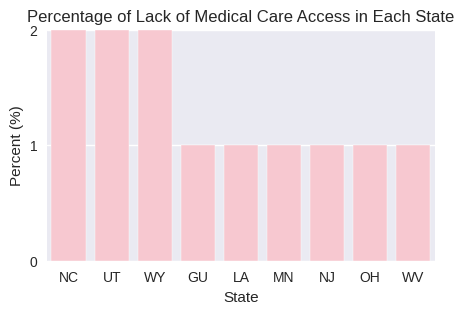

In [ ]:
# Visualizing 3.13 Table
plotting_df = result_df[['State', 'Percent']]

# There are many 0s in this data, so we will only include State > 0 values in the visual
plotting_df = plotting_df[plotting_df['Percent'] > 0]

plt.figure(figsize=(5, 3))
ax = sns.barplot(plotting_df, x='State', y='Percent', color='pink')
ax.set_yticks(range(0,3))
ax.set_ylim(0, 2)
plt.title('Percentage of Lack of Medical Care Access in Each State')
plt.ylabel('Percent (%)')

We have noticed that there is not a significant correlation based on Figure (add here number later). It seems to be adding unnecessary noise to our data, so we have decided to drop the State column and focus on other features. Once we do the one-hot encoding, the State column will unreasonably bloat the data.

In [ ]:
# # Dropping State column from dataset
df_with_state  = df.copy()
df = df.drop(['State'], axis=1)

## **3.14** Correlation of Heart Attack with non-categorical features

In [ ]:
# Select particular age groups
features_columns = df.columns
features_columns = features_columns.drop(['Sex', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AgeCategory', 'TetanusLast10Tdap', 'BMI_Category'])

# Calculate correlations
correlations2 = df[features_columns].corrwith(df['HadHeartAttack']).sort_values(ascending=False)

corr2_table = pd.DataFrame(correlations2)
display(corr2_table)

,0
HadHeartAttack,1.000000
HadAngina,0.445902
HadStroke,0.177149
ChestScan,0.167766
DifficultyWalking,0.159884
HadDiabetes,0.139790
PhysicalHealthDays,0.133422
HadCOPD,0.133220
PneumoVaxEver,0.119965
HadArthritis,0.117772


## **3.15** ANALYSIS (Correlation)

**Analysis**:
1. The strongest correlation of 'HadHeartAttack' is with 'HadAngina', i.e. **0.45**
2. There is a negative correlation between the 'HadHeartAttack' and features like, 'HIVTesting', 'CovidPos', 'HighRiskLastYear' and 'AlcoholDrinkers', 'PhysicalActivities'.

In [ ]:
# Select particular age groups
selected_age_groups = ['45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-older']

df_filtered = df[df['AgeCategory'].isin(selected_age_groups)]

features_columns = df_filtered.columns
features_columns = features_columns.drop(['Sex', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AgeCategory', 'TetanusLast10Tdap', 'BMI_Category'])

# Calculate correlations
correlations2 = df_filtered[features_columns].corrwith(df_filtered['HadHeartAttack']).sort_values(ascending=False)

# # Print correlations
# print('\nCorrelation of Heart Attack In Age 45-Older:\n',correlations2)

corr2_table = pd.DataFrame(correlations2)
display(corr2_table)

,0
HadHeartAttack,1.000000
HadAngina,0.444291
HadStroke,0.167265
ChestScan,0.160080
DifficultyWalking,0.143434
PhysicalHealthDays,0.131388
HadDiabetes,0.126140
HadCOPD,0.122713
HadKidneyDisease,0.101183
PneumoVaxEver,0.098415


In [ ]:
# Separating the dataframes

# A = uncontrollable
# B = better habits
# C = access to health care

controllable_df = df[['HadHeartAttack', 'PhysicalActivities', 'SmokerStatus', 'ECigaretteUsage', 'BMI_Category', 'AlcoholDrinkers', 'LastCheckupTime', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap']]
uncontrollable_df = df[['HadHeartAttack', 'AgeCategory', 'RaceEthnicityCategory', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SleepHours', 'HighRiskLastYear', 'CovidPos', 'ChestScan', 'HIVTesting']]

In [ ]:
# Create some EDA to compare the two dataframes
# Find proprtion of individuals who had heart attack for controllable_df vs. uncontrollable_df
# Conduct t-test
# Only want to keep HadHeartAttack = 1
controllable_df = controllable_df[controllable_df['HadHeartAttack'] == 1]
uncontrollable_df = uncontrollable_df[uncontrollable_df['HadHeartAttack'] == 1]

# Null hypothesis: distributions are the same
# Alternative hypothesis: Distributions have significant difference

import numpy as np
import scipy.stats as st




## **3.16** ANALYSIS (Correlation Within Age 45-Older)

Analysis:

The strongest correlation of 'HadHeartAttack' is still with 'HadAngina', i.e. 0.44
The weakest correlation of 'HadHeartAttack' is with 'HighRiskLastYear', 'HIVTesting', 'SleepHours'. But, as seen in the graph, the risk decreases as the sleep hours become optimum (7-8) hours and then rises above. For other features, it needs further exploration.

## **3.17** Feature correlations & Feature reductions

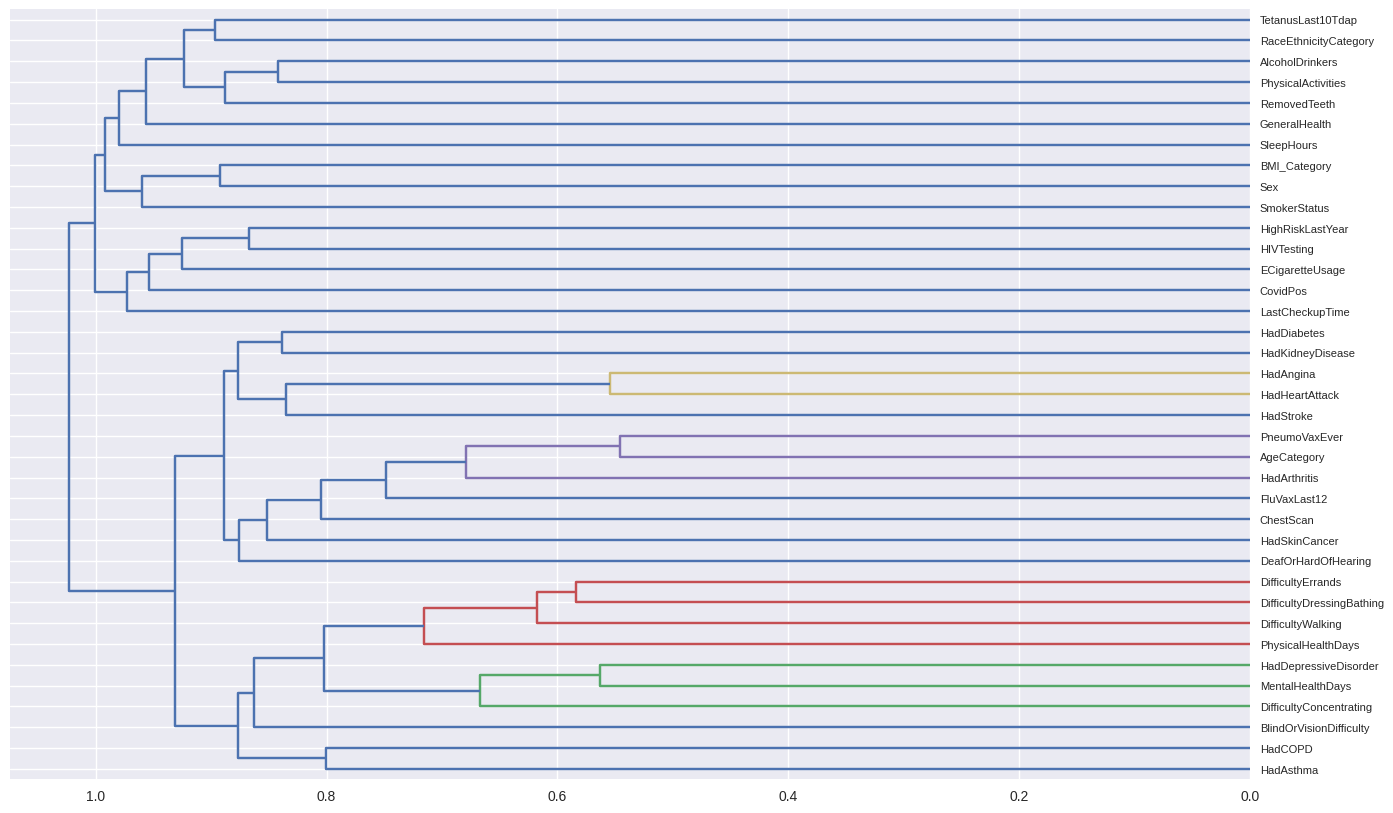

In [ ]:
import scipy
from scipy.cluster import hierarchy as hc

corr = np.round(scipy.stats.spearmanr(df).correlation,4)
corr_condensed = hc.distance.squareform(1-corr)
z=hc.linkage(corr_condensed, method = 'average')
fig = plt.figure(figsize=(16,10))
dendrogram = hc.dendrogram(z,labels= df.columns,orientation='left')
plt.show()

From the dendrogram, we can tell that 'DifficultyErrands', 'DifficultyDressingBathing', 'DifficultyWalking' are highly correlated features. 'HadDepressiveDisorder and MentalHealthDays' are also highhly correlated. We are keeping one of the features in the groups mentioned above.

In [ ]:
# # Dropping State column from dataset
df = df.drop(['DifficultyDressingBathing', 'DifficultyWalking', 'MentalHealthDays'], axis=1)

# **Part IV:** Feature Engineering

## One hot encoding

In [ ]:
encoded_df = pd.get_dummies(df, dtype=int, columns= ['Sex', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AgeCategory', 'TetanusLast10Tdap', 'BMI_Category'])
encoded_df.head(5)

,PhysicalHealthDays,PhysicalActivities,SleepHours,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyErrands,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,HighRiskLastYear,CovidPos,Sex_Female,Sex_Male,GeneralHealth_Excellent,GeneralHealth_Fair,GeneralHealth_Good,GeneralHealth_Poor,GeneralHealth_Very good,LastCheckupTime_< 12 months,LastCheckupTime_>=5 years,LastCheckupTime_[1-2) years,LastCheckupTime_[2-5) years],RemovedTeeth_1 to 5,"RemovedTeeth_6 or more, but not all",RemovedTeeth_All,RemovedTeeth_None of them,SmokerStatus_Everyday,SmokerStatus_Never,SmokerStatus_Not now,SmokerStatus_Some days,ECigaretteUsage_Everyday,ECigaretteUsage_Never,ECigaretteUsage_Not now,ECigaretteUsage_Some days,RaceEthnicityCategory_Black,RaceEthnicityCategory_Hispanic,RaceEthnicityCategory_Multiracial,RaceEthnicityCategory_Other,RaceEthnicityCategory_White,AgeCategory_18-24,AgeCategory_25-29,AgeCategory_30-34,AgeCategory_35-39,AgeCategory_40-44,AgeCategory_45-49,AgeCategory_50-54,AgeCategory_55-59,AgeCategory_60-64,AgeCategory_65-69,AgeCategory_70-74,AgeCategory_75-79,AgeCategory_80-older,TetanusLast10Tdap_Not in past 10 years,TetanusLast10Tdap_Yes but not type Tdap,TetanusLast10Tdap_Yes but type unknown,TetanusLast10Tdap_Yes received Tdap,BMI_Category_Normal,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight
0,4,1,9.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
1,0,1,6.0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0
2,0,0,8.0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0
3,5,1,9.0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0
4,3,1,5.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0


## Label encoding

In [ ]:
label_encoder = preprocessing.LabelEncoder()
cat_data= ['Sex', 'BMI_Category', 'GeneralHealth', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AgeCategory', 'TetanusLast10Tdap']
df2 = df.copy()
for cat in cat_data:
    df2[cat]= label_encoder.fit_transform(df2[cat])
    df2[cat].unique()

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246013 entries, 0 to 246021
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Sex                      246013 non-null  int64  
 1   GeneralHealth            246013 non-null  int64  
 2   PhysicalHealthDays       246013 non-null  int64  
 3   LastCheckupTime          246013 non-null  int64  
 4   PhysicalActivities       246013 non-null  int64  
 5   SleepHours               246013 non-null  float64
 6   RemovedTeeth             246013 non-null  int64  
 7   HadHeartAttack           246013 non-null  int64  
 8   HadAngina                246013 non-null  int64  
 9   HadStroke                246013 non-null  int64  
 10  HadAsthma                246013 non-null  int64  
 11  HadSkinCancer            246013 non-null  int64  
 12  HadCOPD                  246013 non-null  int64  
 13  HadDepressiveDisorder    246013 non-null  int64  
 14  HadKidney

# **Part V:** Modeling (sklearn)

## **5.1** normalize data

Our biggest challenge here is that the dataset is unbalanced.

## **5.2** Splitting data into 'X' & 'y'

In [ ]:
# store all variables as features in 'X' (pd.DataFrame) and 'HadHeartAttack' as target in 'y' (pd.Series)
#X = encoded_df.copy()
X = df2.copy()
X.drop(columns=['HadHeartAttack'], inplace=True)
X.head()

,Sex,GeneralHealth,PhysicalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,BMI_Category,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,0,4,4,0,1,9.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,2,1,0,4,9,2,0,0,1,1,3,0,0
1,1,4,0,0,1,6.0,3,0,0,0,0,0,0,0,1,1,0,0,0,0,2,1,0,4,10,1,0,0,1,1,2,0,0
2,1,4,0,0,0,8.0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,2,1,1,4,11,1,1,0,0,1,0,0,1
3,0,1,5,0,1,9.0,3,0,0,0,1,0,1,0,1,0,0,0,0,0,1,1,0,4,12,1,0,0,1,1,0,0,1
4,0,2,3,0,1,5.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,4,12,1,0,0,1,1,0,0,0


## **5.3** Scaling feature data

In [ ]:
# mix-max scale the data between 0 and 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(X.to_numpy())
X_scaled = pd.DataFrame(scaled, columns=[X.columns])
X_scaled.head()

,Sex,GeneralHealth,PhysicalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,BMI_Category,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,0.0,1.00,0.133333,0.0,1.0,0.347826,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.333333,0.0,1.0,0.750000,0.666667,0.0,0.0,1.0,1.0,1.000000,0.0,0.0
1,1.0,1.00,0.000000,0.0,1.0,0.217391,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.666667,0.333333,0.0,1.0,0.833333,0.333333,0.0,0.0,1.0,1.0,0.666667,0.0,0.0
2,1.0,1.00,0.000000,0.0,0.0,0.304348,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.666667,0.333333,1.0,1.0,0.916667,0.333333,1.0,0.0,0.0,1.0,0.000000,0.0,1.0
3,0.0,0.25,0.166667,0.0,1.0,0.347826,1.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,1.0,1.000000,0.333333,0.0,0.0,1.0,1.0,0.000000,0.0,1.0
4,0.0,0.50,0.100000,0.0,1.0,0.173913,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,1.0,1.000000,0.333333,0.0,0.0,1.0,1.0,0.000000,0.0,0.0


In [ ]:
# store the classification target variable into "target"
y = df2['HadHeartAttack']
y

0         0
1         0
2         0
3         0
4         0
         ..
246017    0
246018    0
246019    0
246020    0
246021    1
Name: HadHeartAttack, Length: 246013, dtype: int64

## **5.4** Splitting 'X, y' into train & test data

In [ ]:
seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

## **5.5** Splitting 'X_scaled, y' into train & test data

In [ ]:
seed = 42
X__scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=seed)

## **5.6** Classification

### **5.6.1** Logistic Regression

accuracy is   0.9481738918358636
********************
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     46558
           1       0.54      0.24      0.33      2645

    accuracy                           0.95     49203
   macro avg       0.75      0.61      0.65     49203
weighted avg       0.94      0.95      0.94     49203



Text(0.5, 1.0, 'Confusion Matrix for Logistic Regression')

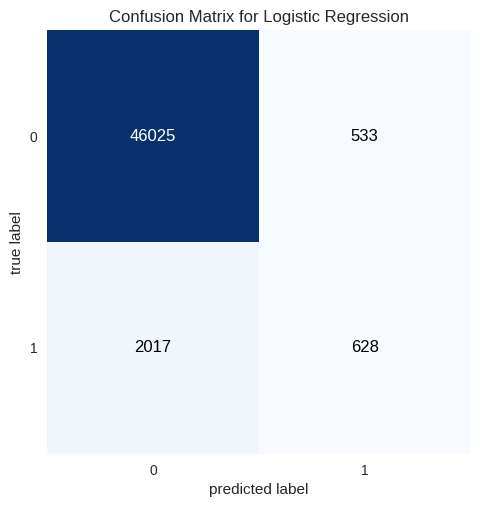

In [ ]:
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_confusion_matrix

# Initialize model with default parameters and fit it on the training set
log = LogisticRegression()
log.fit(X__scaled_train, y_train)

# Use the model to predict on the test set and save these predictions as `y_pred`
y_pred = log.predict(X_scaled_test)

# Find the accuracy and store the value in `log_acc`
log_acc = sklearn.metrics.accuracy_score(y_pred, y_test)

# Compute the confusion matrix and save it to `rf_confusion`
rf_confusion = sklearn.metrics.confusion_matrix(y_test, y_pred)


print("accuracy is  ", log_acc)
print("*" * 20)
print(classification_report(y_test, y_pred))

plot_confusion_matrix(rf_confusion)
plt.title('Confusion Matrix for Logistic Regression')

### **5.6.2** Oversampling / SMOTE

We can tell that our prediction above with heart disease (y = 1) is not very accurate due to the imbalanced dataset. Our recall is only 0.24, which tells us that our model produces many false negatives.

This happens because our dataset is very imbalanced and you can tell that from the confusion matrix. With so few positives relative to negatives, the training model will spend most of its time on negative examples and not learn enough from positive ones.

One approach to addressing imbalanced datasets is to oversample the minority class (people with heart diseases). This can be achieved by simply duplicating examples from the minority class in the training dataset prior to fitting a model. Therefore, for the next step, we are trying Synthetic Minority Oversampling Technique, or SMOTE for short. SMOTE creates new data that contains values that are close to the minority class with the help of data augmentation. These new synthetic training records are made randomly by selecting one or more K-nearest neighbors for each of the minority classes.

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 0)
X_train_smote, Y_train_smote = sm.fit_resample(X__scaled_train, y_train)

X_train, X_test, y_train, y_test = train_test_split(X_train_smote, Y_train_smote, test_size = 0.20, random_state = seed)

In [ ]:
Y_train_smote.value_counts()

HadHeartAttack
0    186020
1    186020
Name: count, dtype: int64

### **5.6.3** Logistic regression with oversampling

accuracy is   0.7999946242339533
********************
              precision    recall  f1-score   support

           0       0.78      0.83      0.81     37166
           1       0.82      0.77      0.79     37242

    accuracy                           0.80     74408
   macro avg       0.80      0.80      0.80     74408
weighted avg       0.80      0.80      0.80     74408



Text(0.5, 1.0, 'Confusion Matrix for Logistic Regression (with oversampling)')

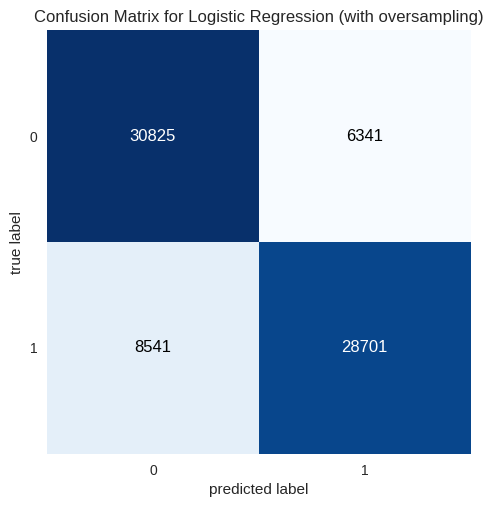

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model with default parameters and fit it on the training set
log = LogisticRegression()
log.fit(X_train, y_train)

# Use the model to predict on the test set and save these predictions as `y_pred`
y_pred = log.predict(X_test)

# Find the accuracy and store the value in `log_acc`
log_acc = sklearn.metrics.accuracy_score(y_pred, y_test)

print("accuracy is  ", log_acc)
print("*" * 20)
print(classification_report(y_test, y_pred))

# Compute the confusion matrix and save it to `rf_confusion`
rf_confusion = sklearn.metrics.confusion_matrix(y_test, y_pred)

plot_confusion_matrix(rf_confusion)
plt.title('Confusion Matrix for Logistic Regression (with oversampling)')

### **5.6.4** Decision Tree with Oversampling

Now we will re-train the Decision Tree Classifier on the oversampled data.

accuracy is   0.951120847220729
********************
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     37166
           1       0.94      0.96      0.95     37242

    accuracy                           0.95     74408
   macro avg       0.95      0.95      0.95     74408
weighted avg       0.95      0.95      0.95     74408



Text(0.5, 1.0, 'Confusion Matrix for Decision Tree')

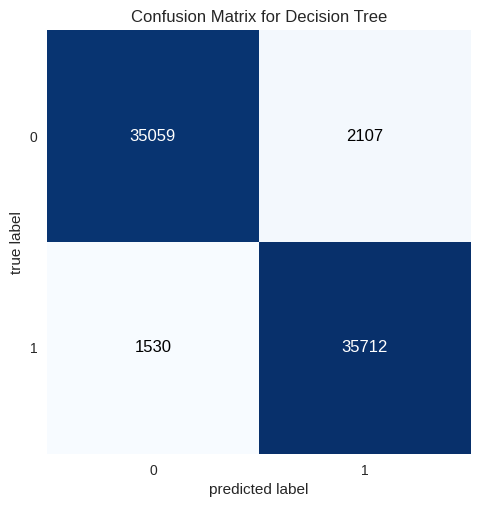

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model with default parameters and fit it on the training set
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# Use the model to predict on the test set and save these predictions as `y_pred`
y_pred = decision_tree.predict(X_test)

# Find the accuracy and store the value in `dec_acc`
dec_acc = sklearn.metrics.accuracy_score(y_pred, y_test)

print("accuracy is  ", dec_acc)
print("*" * 20)
print(classification_report(y_test, y_pred))

# Compute the confusion matrix and save it to `rf_confusion`
rf_confusion = sklearn.metrics.confusion_matrix(y_test, y_pred)
plot_confusion_matrix(rf_confusion)
plt.title('Confusion Matrix for Decision Tree')

### **5.6.5** Random Forest Classifier with Oversampling

accuracy is  0.9743710353725406
--------------------
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     37166
           1       0.98      0.97      0.97     37242

    accuracy                           0.97     74408
   macro avg       0.97      0.97      0.97     74408
weighted avg       0.97      0.97      0.97     74408



Text(0.5, 1.0, 'Confusion Matrix for Random Forest')

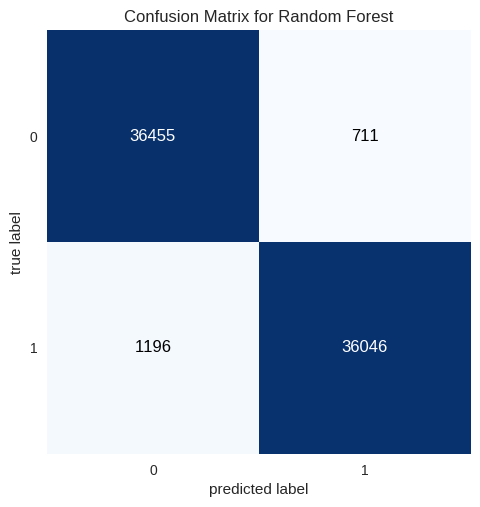

In [ ]:
# Initialize model with default parameters and fit it on the training set
clf = RandomForestClassifier(class_weight = "balanced", n_estimators=120, max_depth=30, random_state=42)
clf.fit(X_train, y_train)

# Use the model to predict on the test set and save these predictions as `y_pred`
y_pred = clf.predict(X_test)

# Find the accuracy and store the value in `rf_acc`
rf_acc = sklearn.metrics.accuracy_score(y_pred, y_test)

# Compute the confusion matrix and save it to `rf_confusion`
rf_confusion = sklearn.metrics.confusion_matrix(y_test, y_pred)

print("accuracy is ", rf_acc)
print("-" * 20)
plot_confusion_matrix(rf_confusion)
print(classification_report(y_test, y_pred))

plt.title('Confusion Matrix for Random Forest')

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     37166
           1       0.98      0.97      0.97     37242

    accuracy                           0.97     74408
   macro avg       0.97      0.97      0.97     74408
weighted avg       0.97      0.97      0.97     74408



Now take a look at the scores for heart diseases (y=1). It is MUCH better! If we look at the confusion matrix, we can see that there are an equal number of positive samples as negative samples.

## **5.7** Model Evaluation

### ROC Curve and AUC

So far, we have used confusion matrix, accuracy, precision, recall, F1 score to evaluate the models. What is a much more robust assessment is to have a measure of classification metrics across multiple thresholds.

The ROC curve is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at various threshold settings. The ROC curve essentially compares the models TPR and FPR to a random assignment. The frequencies of the TPs and FPs change as we change the threshold criterion.

The AUC stands for area under the ROC. The total area is equal to 1. When ROC is a straight line diagonal the AUC =0.5. This indicates the model is no better than random assignment for prediction purposes at any threshold. A very good AUC is a value close to 1.

In [ ]:
# predict probabilities
pred_prob1 = log.predict_proba(X_test)
pred_prob2 = decision_tree.predict_proba(X_test)
pred_prob3 = clf.predict_proba(X_test)

In [ ]:
from sklearn.metrics import roc_curve

# roc curve for models
fpr1, tpr1, thresh1 = roc_curve(y_test, pred_prob1[:,1], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, pred_prob2[:,1], pos_label=1)
fpr3, tpr3, thresh3 = roc_curve(y_test, pred_prob3[:,1], pos_label=1)

# roc curve for tpr = fpr
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

Computing the AUC score next

In [ ]:
from sklearn.metrics import roc_auc_score

# auc scores
auc_score1 = roc_auc_score(y_test, pred_prob1[:,1])
auc_score2 = roc_auc_score(y_test, pred_prob2[:,1])
auc_score3 = roc_auc_score(y_test, pred_prob3[:,1])

print(auc_score1, auc_score2, auc_score3)

0.887746792083691 0.9511458974428132 0.996540777853467


<ipython-input-301-61304fc7da63>:1: MatplotlibDeprecationWarning:

The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.



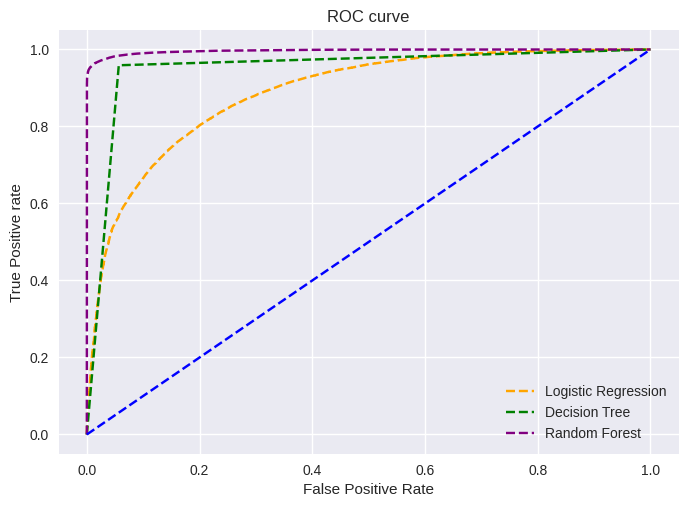

In [ ]:
plt.style.use('seaborn')

# plot roc curves
plt.plot(fpr1, tpr1, linestyle='--',color='orange', label='Logistic Regression')
plt.plot(fpr2, tpr2, linestyle='--',color='green', label='Decision Tree')
plt.plot(fpr3, tpr3, linestyle='--',color='purple', label='Random Forest')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# title
plt.title('ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.show()

## **5.8** Evaluating Important Features based on Random Forest Classifier Model

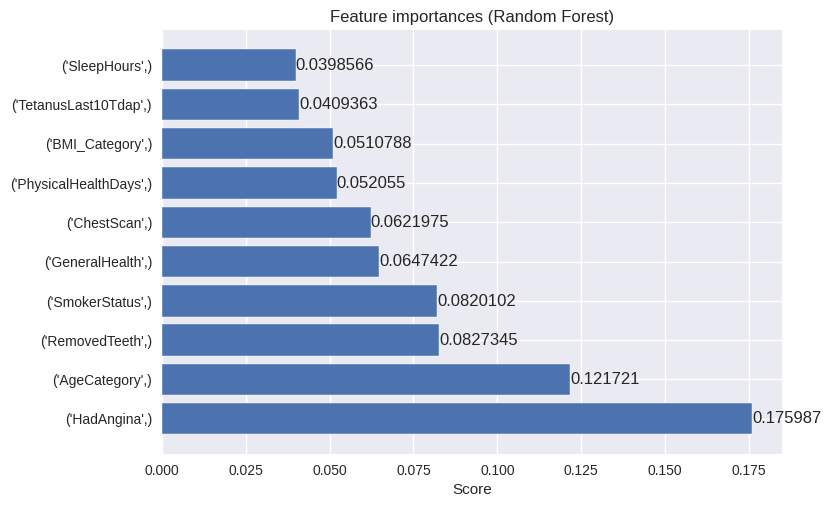

In [ ]:
# Plotting the 15 most important features
headers = ["name", "score"]
values = sorted(zip(X__scaled_train.columns, clf.feature_importances_), key=lambda x: x[1],reverse=True)
forest_feature_importances = pd.DataFrame(values, columns = headers)


features = forest_feature_importances['name'][:10]

y_pos = np.arange(len(features))
scores = forest_feature_importances['score'][:10]

#plot feature importances
features_plot = plt.barh(y_pos,scores)
plt.yticks(y_pos, features)
plt.xlabel('Score')
plt.title('Feature importances (Random Forest)')
plt.bar_label(features_plot, label_type="edge")

plt.show()